# Used Cars Price Prediction

**Domain:** Price Prediction  
**Project:** Data Science with Python – Capstone Project

## Context
MyCars is a new-age startup in the used car resell domain. This project builds a machine learning model to predict the selling price of second-hand cars, and identifies the key features that drive the price.

## Objectives
1. Provide the best-performing model to determine the price of a used car.
2. Identify the most important features which determine the price.

## Steps
1. Import Libraries & Load Dataset
2. Exploratory Data Analysis (EDA)  
   – Univariate Analysis  
   – Multivariate Analysis
3. Data Preprocessing & Feature Engineering
4. Layout Regression Experiment Space
5. Model Performance on Hold-out Test Set
6. Feature Importance Analysis

---
## 1. Import Libraries and Load Dataset

In [1]:
# Core
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

print('Libraries imported successfully.')

Libraries imported successfully.


In [2]:
DATA_PATH = 'dataset/cars.csv'
df = pd.read_csv(DATA_PATH)
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (1725, 11)


,Id,year,brand,full_model_name,model_name,price,distance_travelled(kms),fuel_type,city,brand_rank,car_age
0,0,2016,Honda,Honda Brio S MT,Brio,425000.00,9680.00,Petrol,Mumbai,7,5.00
1,1,2012,Nissan,Nissan Sunny XV Diesel,Sunny,325000.00,119120.00,Diesel,Mumbai,11,9.00
2,2,2017,Toyota,Toyota Fortuner 2.8 4x2 MT [2016-2020],Fortuner,2650000.00,64593.00,Diesel,Thane,1,4.00
3,3,2017,Mercedes-Benz,Mercedes-Benz E-Class E 220d Expression [2019-...,E-Class,4195000.00,25000.00,Diesel,Mumbai,2,4.00
4,4,2012,Hyundai,Hyundai Verna Fluidic 1.6 CRDi SX,Verna,475000.00,23800.00,Diesel,Mumbai,14,9.00


---
## 2. Exploratory Data Analysis

### 2.1 Basic Info & Quality Checks

In [3]:
print('=== Dataset Info ===')
df.info()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1725 entries, 0 to 1724
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Id                       1725 non-null   int64  
 1   year                     1725 non-null   int64  
 2   brand                    1725 non-null   object 
 3   full_model_name          1725 non-null   object 
 4   model_name               1725 non-null   object 
 5   price                    1725 non-null   float64
 6   distance_travelled(kms)  1725 non-null   float64
 7   fuel_type                1725 non-null   object 
 8   city                     1725 non-null   object 
 9   brand_rank               1725 non-null   int64  
 10  car_age                  1725 non-null   float64
dtypes: float64(3), int64(3), object(5)
memory usage: 148.4+ KB


In [4]:
print('=== Statistical Summary ===')
df.describe(include='all')

=== Statistical Summary ===


,Id,year,brand,full_model_name,model_name,price,distance_travelled(kms),fuel_type,city,brand_rank,car_age
count,1725.00,1725.00,1725,1725,1725,1725.00,1725.00,1725,1725,1725.00,1725.00
unique,NaN,NaN,31,750,169,NaN,NaN,5,15,NaN,NaN
top,NaN,NaN,Hyundai,Ford EcoSport Titanium 1.5L TDCi,Creta,NaN,NaN,Diesel,Chennai,NaN,NaN
freq,NaN,NaN,297,12,71,NaN,NaN,922,493,NaN,NaN
mean,862.00,2015.39,NaN,NaN,NaN,1494837.39,53848.26,NaN,NaN,15.73,5.61
std,498.11,3.21,NaN,NaN,NaN,1671657.73,44725.54,NaN,NaN,12.95,3.21
min,0.00,1990.00,NaN,NaN,NaN,62500.00,350.00,NaN,NaN,1.00,0.00
25%,431.00,2013.00,NaN,NaN,NaN,545000.00,29000.00,NaN,NaN,5.00,3.00
50%,862.00,2016.00,NaN,NaN,NaN,875000.00,49000.00,NaN,NaN,14.00,5.00
75%,1293.00,2018.00,NaN,NaN,NaN,1825000.00,70500.00,NaN,NaN,24.00,8.00


In [5]:
print('=== Missing Values ===')
missing = df.isnull().sum()
pct = missing / len(df) * 100
pd.DataFrame({'Count': missing, 'Pct (%)': pct})

=== Missing Values ===


,Count,Pct (%)
Id,0,0.00
year,0,0.00
brand,0,0.00
full_model_name,0,0.00
model_name,0,0.00
price,0,0.00
distance_travelled(kms),0,0.00
fuel_type,0,0.00
city,0,0.00
brand_rank,0,0.00


In [6]:
print(f'Duplicate rows: {df.duplicated().sum()}')

Duplicate rows: 0


### 2.2 Univariate Analysis

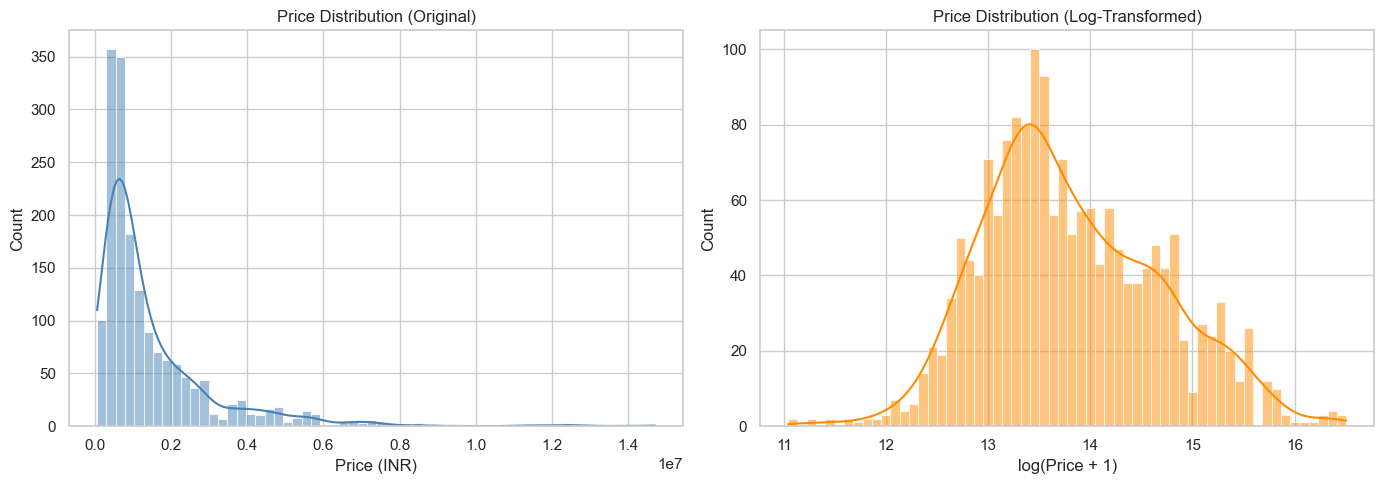

In [7]:
# ---- Target variable: price ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['price'], bins=60, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Price Distribution (Original)')
axes[0].set_xlabel('Price (INR)')

sns.histplot(np.log1p(df['price']), bins=60, kde=True, ax=axes[1], color='darkorange')
axes[1].set_title('Price Distribution (Log-Transformed)')
axes[1].set_xlabel('log(Price + 1)')

plt.tight_layout()
plt.show()

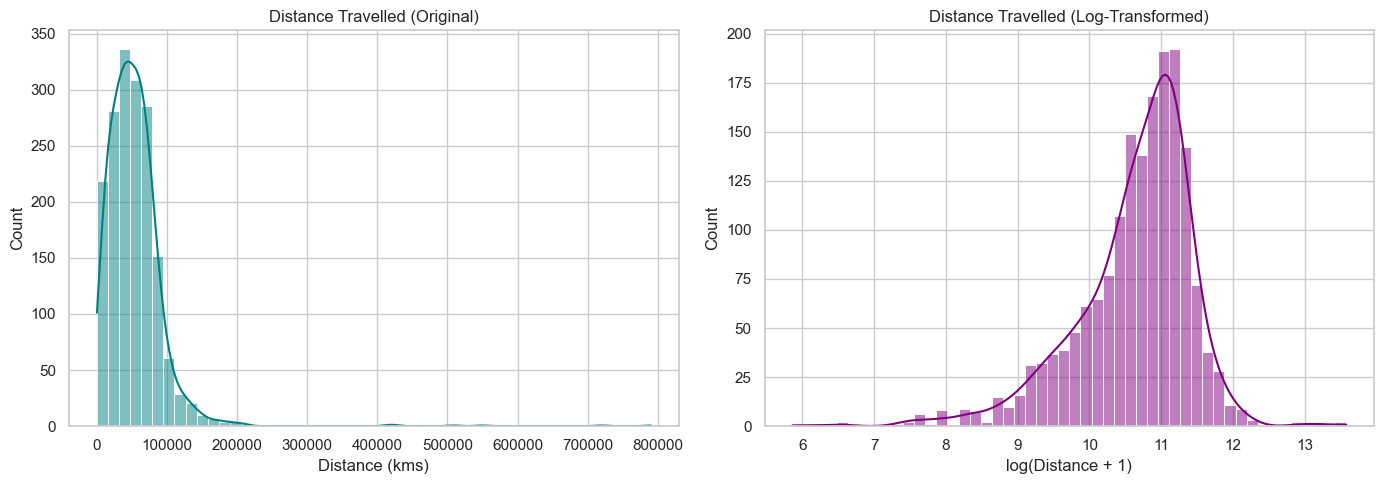

In [8]:
# ---- Distance travelled ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['distance_travelled(kms)'], bins=50, kde=True, ax=axes[0], color='teal')
axes[0].set_title('Distance Travelled (Original)')
axes[0].set_xlabel('Distance (kms)')

sns.histplot(np.log1p(df['distance_travelled(kms)']), bins=50, kde=True,
             ax=axes[1], color='purple')
axes[1].set_title('Distance Travelled (Log-Transformed)')
axes[1].set_xlabel('log(Distance + 1)')

plt.tight_layout()
plt.show()

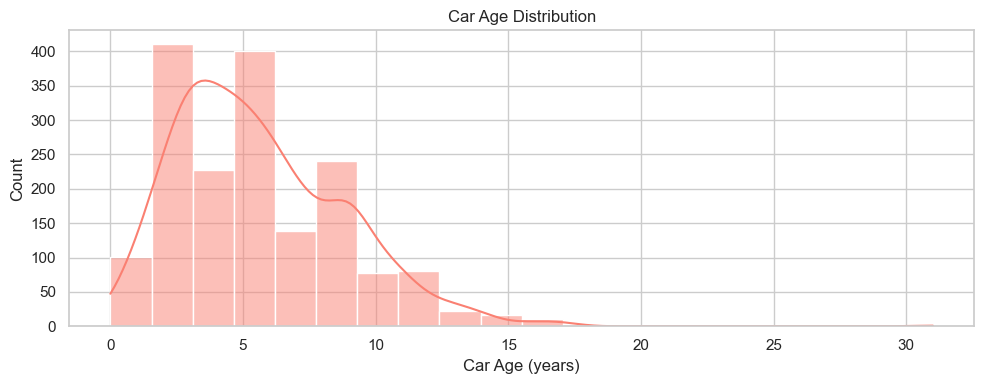

In [9]:
# ---- Car age ----
plt.figure(figsize=(10, 4))
sns.histplot(df['car_age'], bins=20, kde=True, color='salmon')
plt.title('Car Age Distribution')
plt.xlabel('Car Age (years)')
plt.tight_layout()
plt.show()

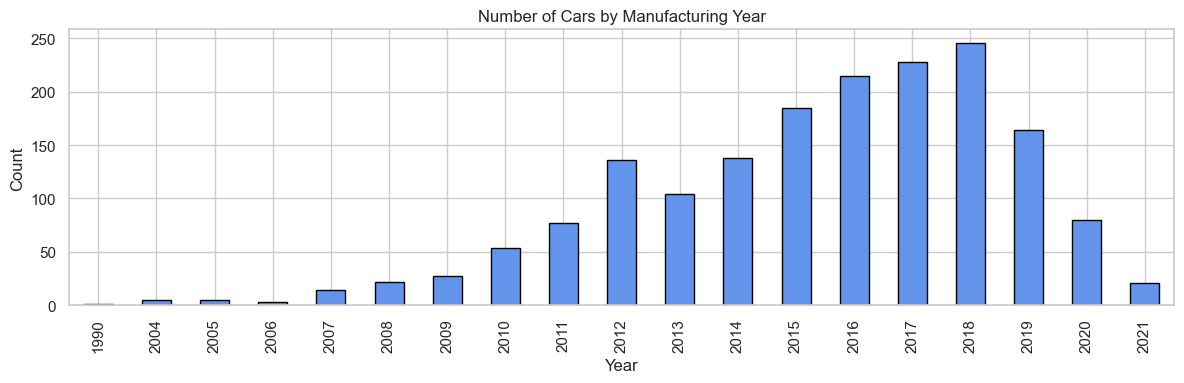

In [10]:
# ---- Manufacturing year ----
plt.figure(figsize=(12, 4))
df['year'].value_counts().sort_index().plot(kind='bar',
                                             color='cornflowerblue', edgecolor='black')
plt.title('Number of Cars by Manufacturing Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

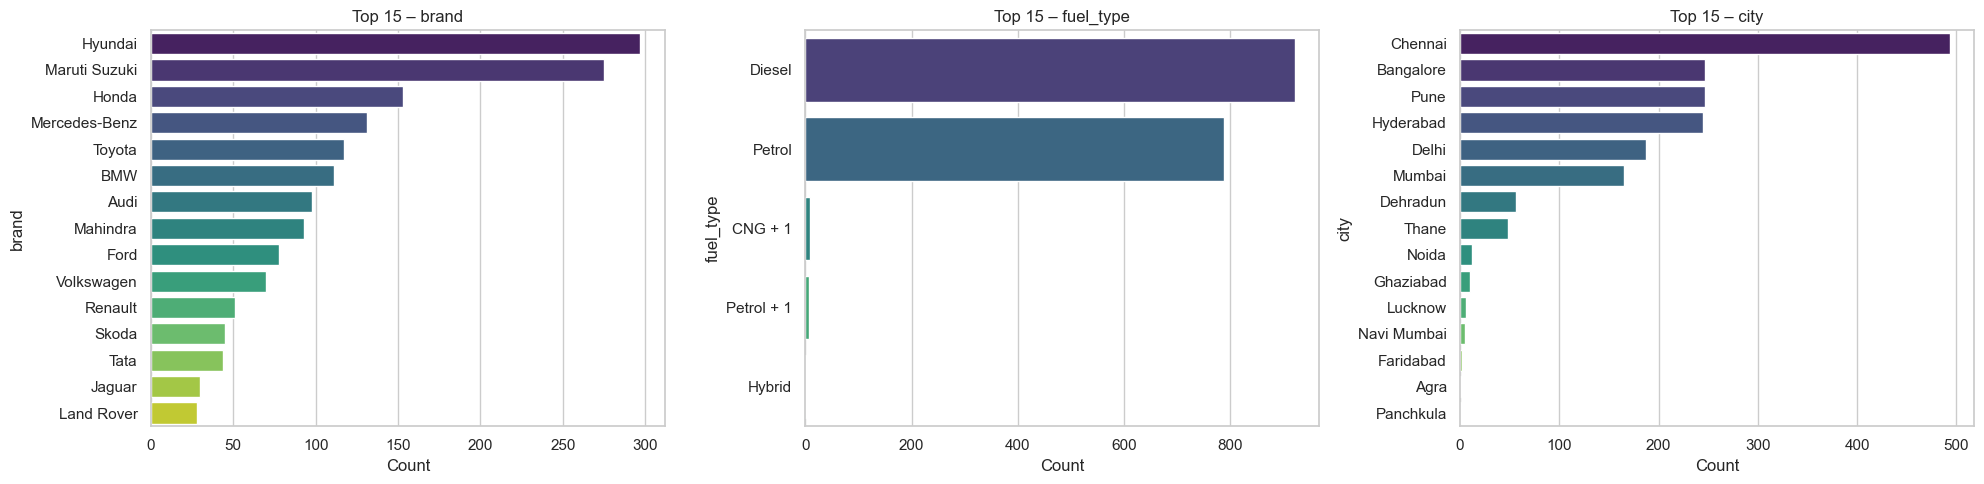

In [11]:
# ---- Categorical features ----
cat_cols = ['brand', 'fuel_type', 'city']
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, col in zip(axes, cat_cols):
    counts = df[col].value_counts().head(15)
    sns.barplot(x=counts.values, y=counts.index, ax=ax, palette='viridis')
    ax.set_title(f'Top 15 – {col}')
    ax.set_xlabel('Count')

plt.tight_layout()
plt.show()

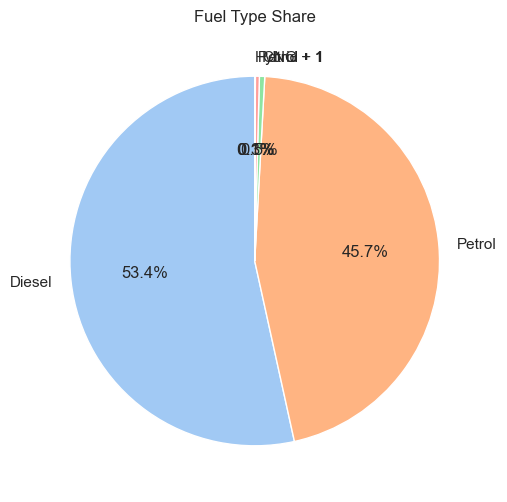

In [12]:
# ---- Fuel type share ----
plt.figure(figsize=(6, 6))
df['fuel_type'].value_counts().plot.pie(
    autopct='%1.1f%%', startangle=90,
    colors=sns.color_palette('pastel')
)
plt.title('Fuel Type Share')
plt.ylabel('')
plt.show()

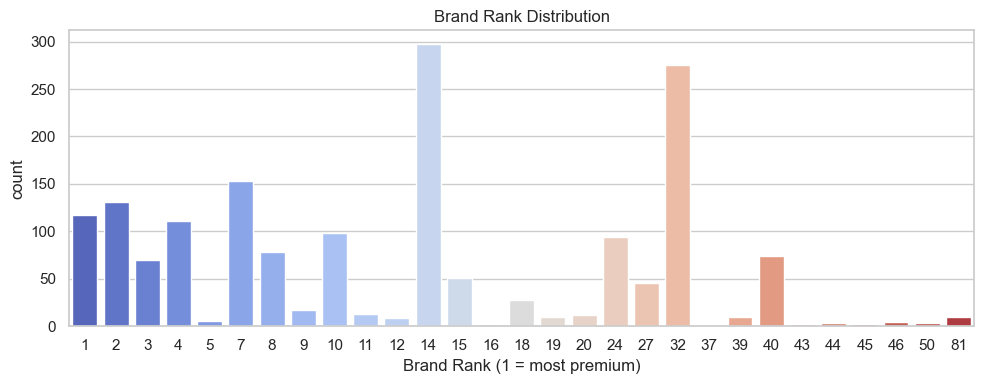

In [13]:
# ---- Brand rank distribution ----
plt.figure(figsize=(10, 4))
sns.countplot(data=df, x='brand_rank', order=sorted(df['brand_rank'].unique()),
              palette='coolwarm')
plt.title('Brand Rank Distribution')
plt.xlabel('Brand Rank (1 = most premium)')
plt.tight_layout()
plt.show()

### 2.3 Multivariate Analysis

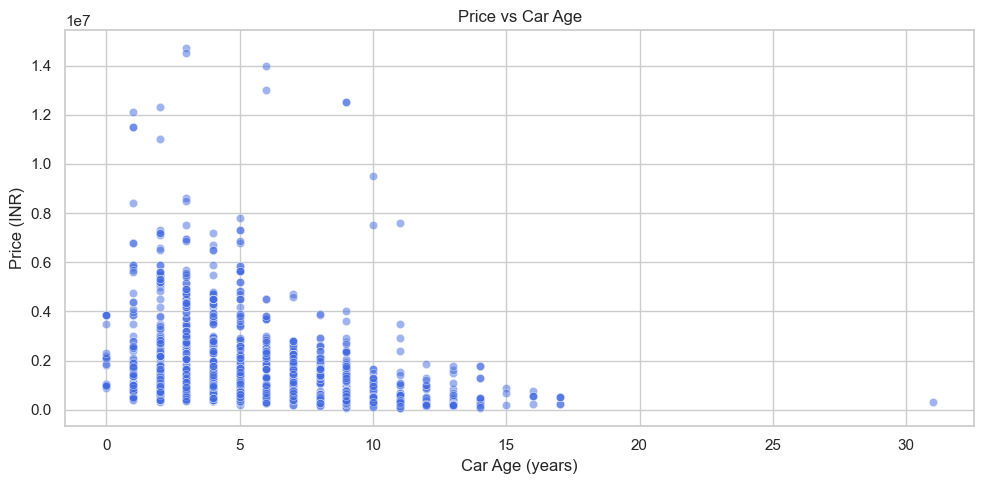

In [14]:
# ---- Price vs Car Age ----
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='car_age', y='price', alpha=0.5, color='royalblue')
plt.title('Price vs Car Age')
plt.xlabel('Car Age (years)')
plt.ylabel('Price (INR)')
plt.tight_layout()
plt.show()

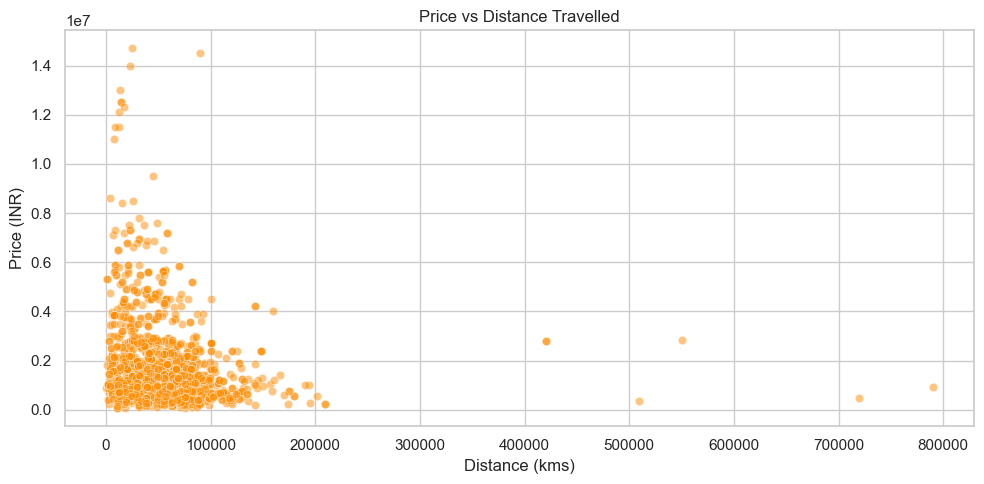

In [15]:
# ---- Price vs Distance Travelled ----
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='distance_travelled(kms)', y='price',
                alpha=0.5, color='darkorange')
plt.title('Price vs Distance Travelled')
plt.xlabel('Distance (kms)')
plt.ylabel('Price (INR)')
plt.tight_layout()
plt.show()

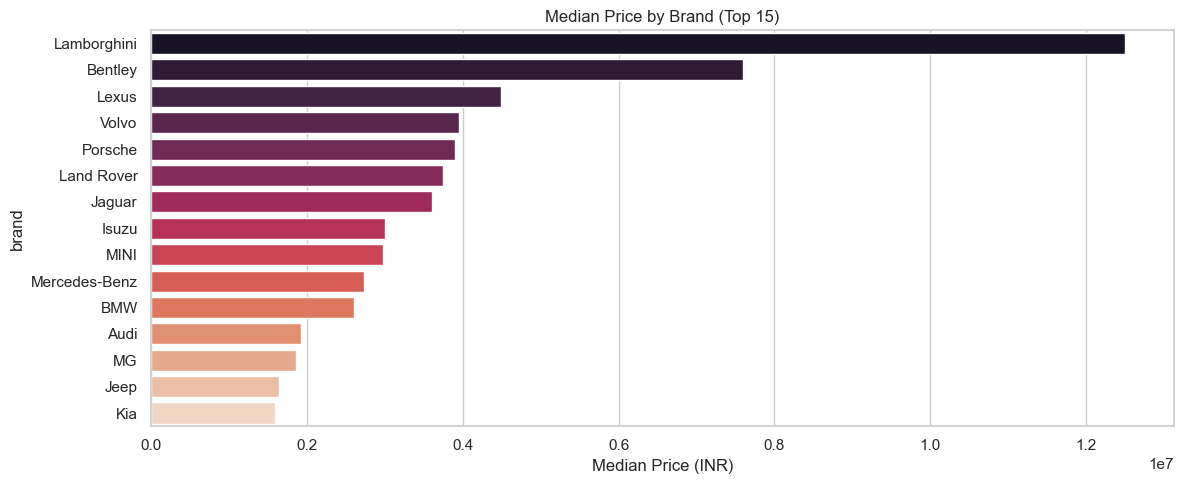

In [16]:
# ---- Median price by brand ----
brand_price = (df.groupby('brand')['price']
                 .median()
                 .sort_values(ascending=False)
                 .head(15))

plt.figure(figsize=(12, 5))
sns.barplot(x=brand_price.values, y=brand_price.index, palette='rocket')
plt.title('Median Price by Brand (Top 15)')
plt.xlabel('Median Price (INR)')
plt.tight_layout()
plt.show()

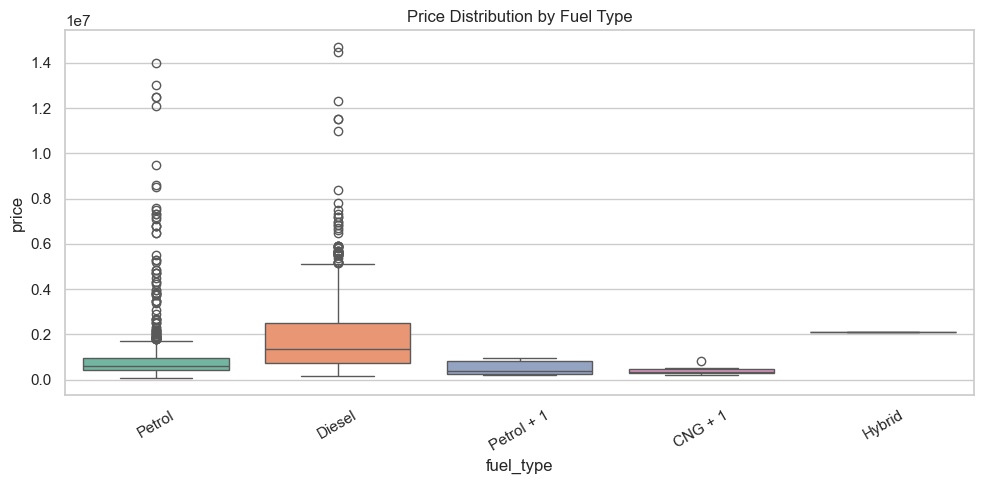

In [17]:
# ---- Price by fuel type ----
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='fuel_type', y='price', palette='Set2')
plt.title('Price Distribution by Fuel Type')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

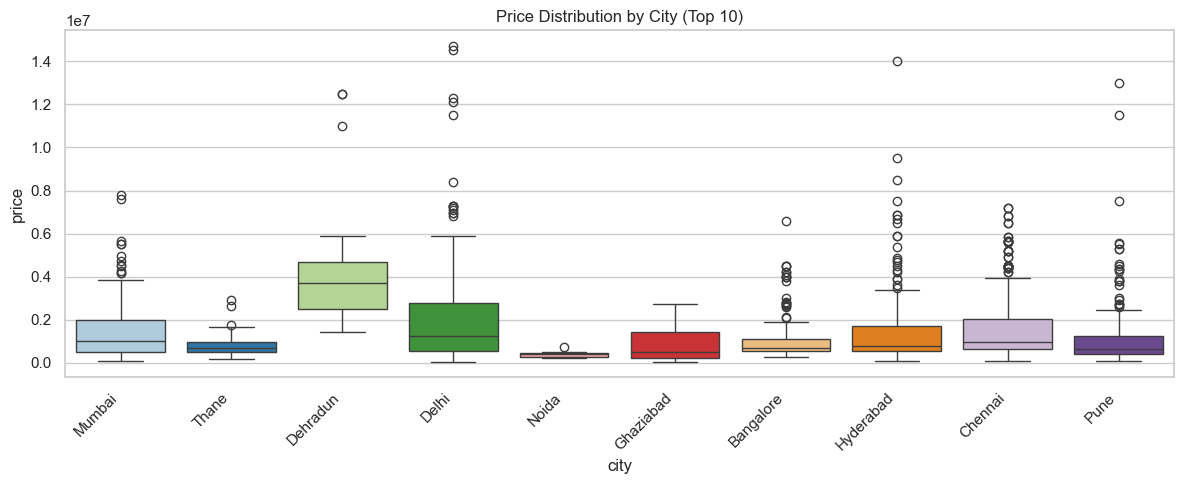

In [18]:
# ---- Price by city (top 10 by volume) ----
top_cities = df['city'].value_counts().head(10).index
plt.figure(figsize=(12, 5))
sns.boxplot(data=df[df['city'].isin(top_cities)],
            x='city', y='price', palette='Paired')
plt.title('Price Distribution by City (Top 10)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

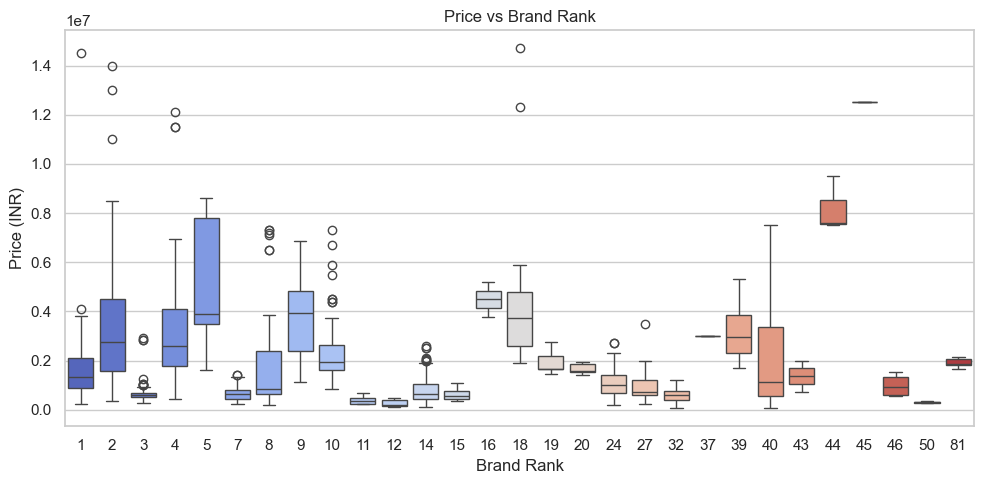

In [19]:
# ---- Price vs Brand Rank ----
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='brand_rank', y='price',
            order=sorted(df['brand_rank'].unique()), palette='coolwarm')
plt.title('Price vs Brand Rank')
plt.xlabel('Brand Rank')
plt.ylabel('Price (INR)')
plt.tight_layout()
plt.show()

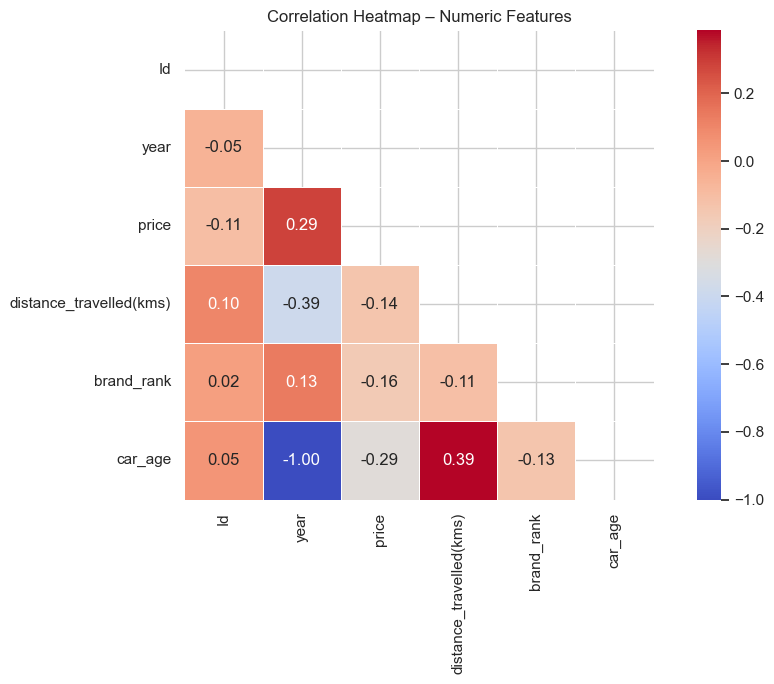

In [20]:
# ---- Correlation heatmap ----
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[num_cols].corr()

plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5, square=True)
plt.title('Correlation Heatmap – Numeric Features')
plt.tight_layout()
plt.show()

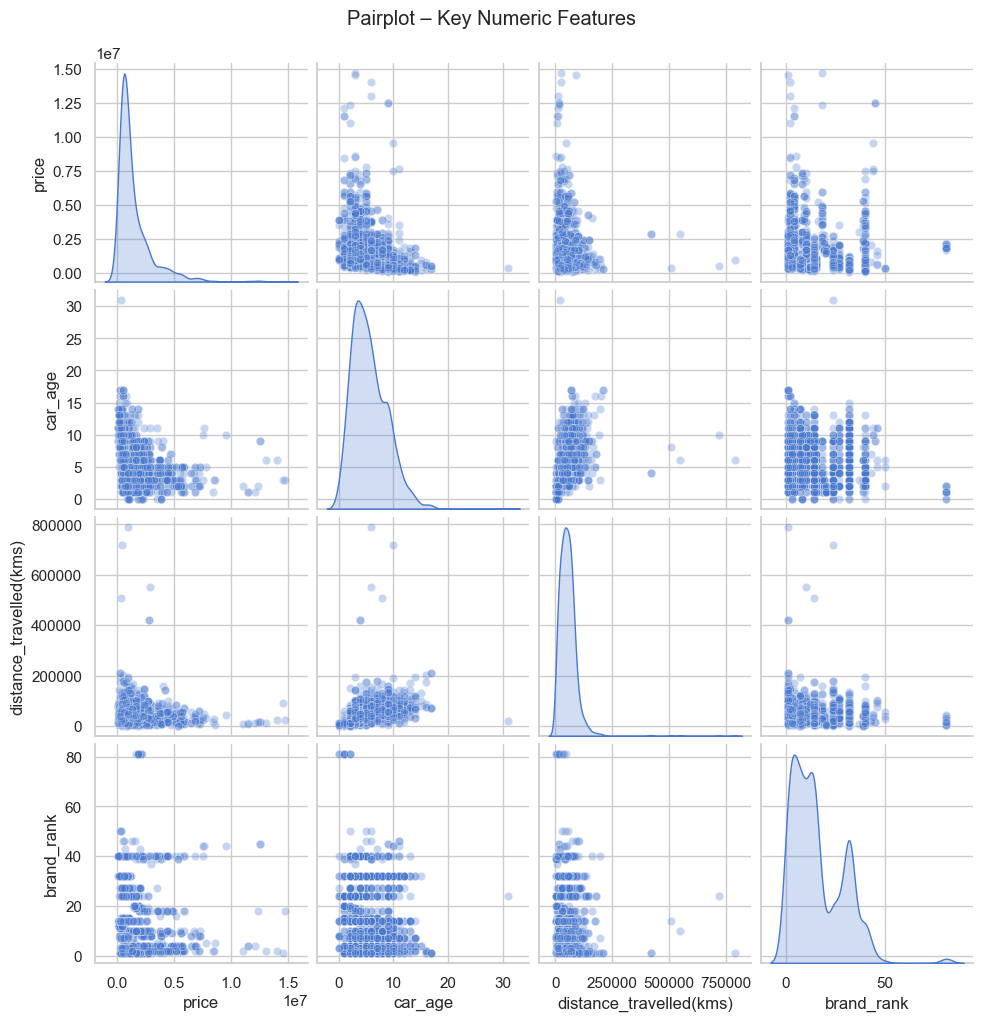

In [21]:
# ---- Pairplot ----
pair_cols = ['price', 'car_age', 'distance_travelled(kms)', 'brand_rank']
sns.pairplot(df[pair_cols].dropna(), plot_kws={'alpha': 0.3}, diag_kind='kde')
plt.suptitle('Pairplot – Key Numeric Features', y=1.02)
plt.show()

---
## 3. Data Preprocessing & Feature Engineering

In [22]:
data = df.copy()

# Drop non-predictive / high-cardinality columns
data.drop(columns=['Id', 'full_model_name', 'year'], inplace=True)
# 'year' is perfectly collinear with 'car_age'; drop to avoid redundancy

print('Columns retained:', data.columns.tolist())

Columns retained: ['brand', 'model_name', 'price', 'distance_travelled(kms)', 'fuel_type', 'city', 'brand_rank', 'car_age']


In [23]:
# Handle missing values (none expected in this dataset, but defensive handling)
for col in data.select_dtypes(include=[np.number]).columns:
    data[col].fillna(data[col].median(), inplace=True)
for col in data.select_dtypes(include='object').columns:
    data[col].fillna(data[col].mode()[0], inplace=True)

data.drop_duplicates(inplace=True)
print(f'Shape after dedup: {data.shape}  | Missing: {data.isnull().sum().sum()}')

Shape after dedup: (1295, 8)  | Missing: 0


In [24]:
# Outlier treatment – IQR clipping (factor = 3)
def clip_iqr(series, factor=3.0):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return series.clip(Q1 - factor * IQR, Q3 + factor * IQR)

data['price'] = clip_iqr(data['price'])
data['distance_travelled(kms)'] = clip_iqr(data['distance_travelled(kms)'])
print('Outlier clipping applied.')

Outlier clipping applied.


In [25]:
# Log-transform skewed numeric features
data['log_distance'] = np.log1p(data['distance_travelled(kms)'])
data.drop(columns=['distance_travelled(kms)'], inplace=True)

# Log-transform target
data['log_price'] = np.log1p(data['price'])

print('Feature engineering done.')

Feature engineering done.


In [26]:
# Label-encode categorical columns
cat_cols = data.select_dtypes(include='object').columns.tolist()
print('Encoding:', cat_cols)

le_map = {}
for col in cat_cols:
    le = LabelEncoder()
    data[col + '_enc'] = le.fit_transform(data[col].astype(str))
    le_map[col] = le

data.drop(columns=cat_cols, inplace=True)
data.head()

Encoding: ['brand', 'model_name', 'fuel_type', 'city']


,price,brand_rank,car_age,log_distance,log_price,brand_enc,model_name_enc,fuel_type_enc,city_enc
0,425000.00,7,5.00,9.18,12.96,7,28,3,9
1,325000.00,11,9.00,11.69,12.69,23,129,1,9
2,2650000.00,1,4.00,11.08,14.79,28,69,1,14
3,4195000.00,2,4.00,10.13,15.25,21,51,1,9
4,475000.00,14,9.00,10.08,13.07,8,144,1,9


In [27]:
# Features & target
TARGET = 'log_price'
X = data.drop(columns=['price', TARGET])
y = data[TARGET]

print(f'Features ({X.shape[1]}): {X.columns.tolist()}')
print(f'Samples : {X.shape[0]}')

Features (7): ['brand_rank', 'car_age', 'log_distance', 'brand_enc', 'model_name_enc', 'fuel_type_enc', 'city_enc']
Samples : 1295


In [28]:
# Train / Test split  (80 / 20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

# Scaled versions for linear models
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

Train: (1036, 7)  |  Test: (259, 7)


---
## 4. Layout Regression Experiment Space

| # | Model |
|---|-------|
| 1 | Linear Regression |
| 2 | Ridge Regression |
| 3 | Lasso Regression |
| 4 | Decision Tree |
| 5 | Random Forest |
| 6 | Gradient Boosting |
| 7 | XGBoost |
| 8 | LightGBM |

In [29]:
def evaluate(name, model, Xtr, ytr, Xte, yte):
    model.fit(Xtr, ytr)
    y_pred_log = model.predict(Xte)

    y_pred = np.expm1(y_pred_log)
    y_true = np.expm1(yte.values)

    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    cv_r2 = cross_val_score(model, Xtr, ytr, cv=5, scoring='r2').mean()

    return {
        'Model'        : name,
        'CV R2 (train)': round(cv_r2, 4),
        'Test MAE'     : round(mae, 2),
        'Test RMSE'    : round(rmse, 2),
        'Test R2'      : round(r2, 4),
    }

results = []

In [30]:
# 1 – Linear Regression
lr = LinearRegression()
results.append(evaluate('Linear Regression', lr, X_train_sc, y_train, X_test_sc, y_test))

# 2 – Ridge
ridge = Ridge(alpha=10.0)
results.append(evaluate('Ridge Regression', ridge, X_train_sc, y_train, X_test_sc, y_test))

# 3 – Lasso
lasso = Lasso(alpha=0.001, max_iter=5000)
results.append(evaluate('Lasso Regression', lasso, X_train_sc, y_train, X_test_sc, y_test))

print('Linear models done.')

Linear models done.


In [31]:
# 4 – Decision Tree
dt = DecisionTreeRegressor(max_depth=8, min_samples_leaf=5, random_state=42)
results.append(evaluate('Decision Tree', dt, X_train, y_train, X_test, y_test))

# 5 – Random Forest
rf = RandomForestRegressor(n_estimators=200, max_depth=12,
                            min_samples_leaf=3, n_jobs=-1, random_state=42)
results.append(evaluate('Random Forest', rf, X_train, y_train, X_test, y_test))

# 6 – Gradient Boosting
gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                                max_depth=5, random_state=42)
results.append(evaluate('Gradient Boosting', gb, X_train, y_train, X_test, y_test))

print('Tree-based models done.')

Tree-based models done.


In [32]:
# 7 – XGBoost
xgb_model = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6,
                          subsample=0.8, colsample_bytree=0.8,
                          n_jobs=-1, random_state=42, verbosity=0)
results.append(evaluate('XGBoost', xgb_model, X_train, y_train, X_test, y_test))

# 8 – LightGBM
lgbm_model = LGBMRegressor(n_estimators=300, learning_rate=0.05, max_depth=6,
                             num_leaves=63, subsample=0.8, colsample_bytree=0.8,
                             n_jobs=-1, random_state=42, verbose=-1)
results.append(evaluate('LightGBM', lgbm_model, X_train, y_train, X_test, y_test))

print('Boosting models done.')

Boosting models done.


---
## 5. Model Performance on Hold-out Test Set

In [33]:
results_df = (pd.DataFrame(results)
                .sort_values('Test R2', ascending=False)
                .reset_index(drop=True))
results_df.index += 1
print('=== Model Comparison on Hold-out Test Set ===')
results_df

=== Model Comparison on Hold-out Test Set ===


,Model,CV R2 (train),Test MAE,Test RMSE,Test R2
1,XGBoost,0.85,260370.19,553548.24,0.84
2,LightGBM,0.81,284360.43,581340.91,0.82
3,Gradient Boosting,0.84,303184.07,631821.04,0.79
4,Random Forest,0.73,346320.58,657868.31,0.77
5,Decision Tree,0.54,428081.70,752123.93,0.70
6,Linear Regression,0.42,678837.44,1124838.49,0.32
7,Lasso Regression,0.42,679461.02,1125979.70,0.32
8,Ridge Regression,0.42,680053.89,1127186.92,0.32


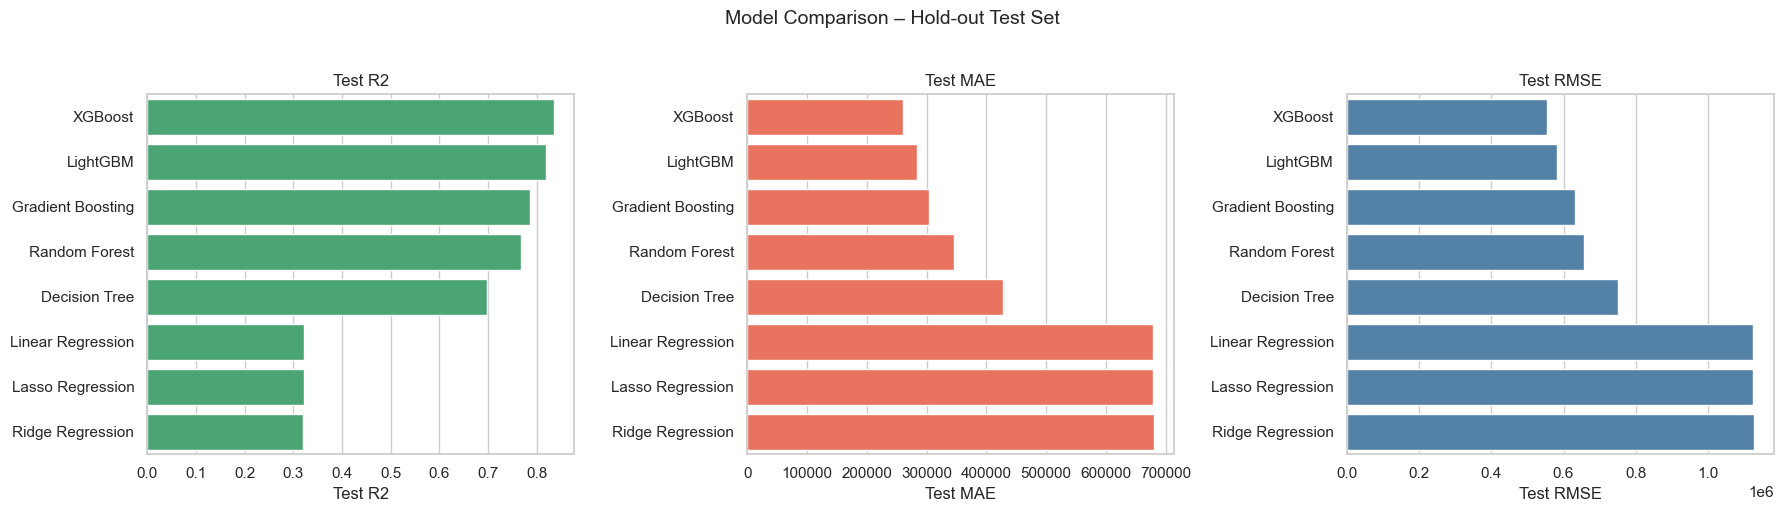

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metric_cfg = [
    ('Test R2',   'mediumseagreen', False),
    ('Test MAE',  'tomato',         True),
    ('Test RMSE', 'steelblue',      True),
]

for ax, (metric, color, asc) in zip(axes, metric_cfg):
    sdf = results_df.sort_values(metric, ascending=asc)
    sns.barplot(x=metric, y='Model', data=sdf,
                color=color, ax=ax)
    ax.set_title(f'{metric}')
    ax.set_ylabel('')

plt.suptitle('Model Comparison – Hold-out Test Set', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [35]:
best_row  = results_df.iloc[0]
best_name = best_row['Model']
print(f'Best Model : {best_name}')
print(f'  Test R²  : {best_row["Test R2"]}')
print(f'  Test MAE : {best_row["Test MAE"]}')
print(f'  Test RMSE: {best_row["Test RMSE"]}')

Best Model : XGBoost
  Test R²  : 0.836
  Test MAE : 260370.19
  Test RMSE: 553548.24


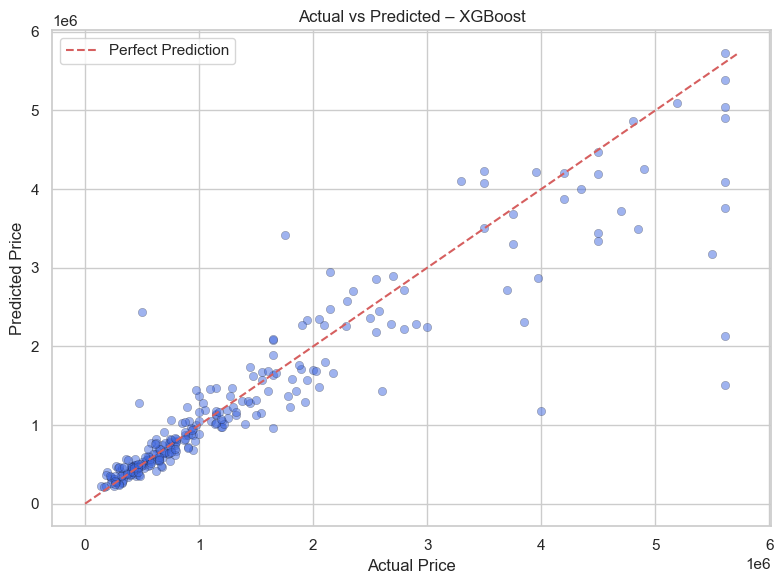

In [36]:
# Actual vs Predicted – best model
model_registry = {
    'Linear Regression' : (lr,         X_test_sc),
    'Ridge Regression'  : (ridge,      X_test_sc),
    'Lasso Regression'  : (lasso,      X_test_sc),
    'Decision Tree'     : (dt,         X_test),
    'Random Forest'     : (rf,         X_test),
    'Gradient Boosting' : (gb,         X_test),
    'XGBoost'           : (xgb_model,  X_test),
    'LightGBM'          : (lgbm_model, X_test),
}

best_obj, best_Xte = model_registry[best_name]
y_pred_log = best_obj.predict(best_Xte)
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test.values)

plt.figure(figsize=(8, 6))
plt.scatter(y_true, y_pred, alpha=0.5, color='royalblue',
            edgecolors='k', linewidths=0.3)
max_val = max(y_true.max(), y_pred.max())
plt.plot([0, max_val], [0, max_val], 'r--', lw=1.5, label='Perfect Prediction')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title(f'Actual vs Predicted – {best_name}')
plt.legend()
plt.tight_layout()
plt.show()

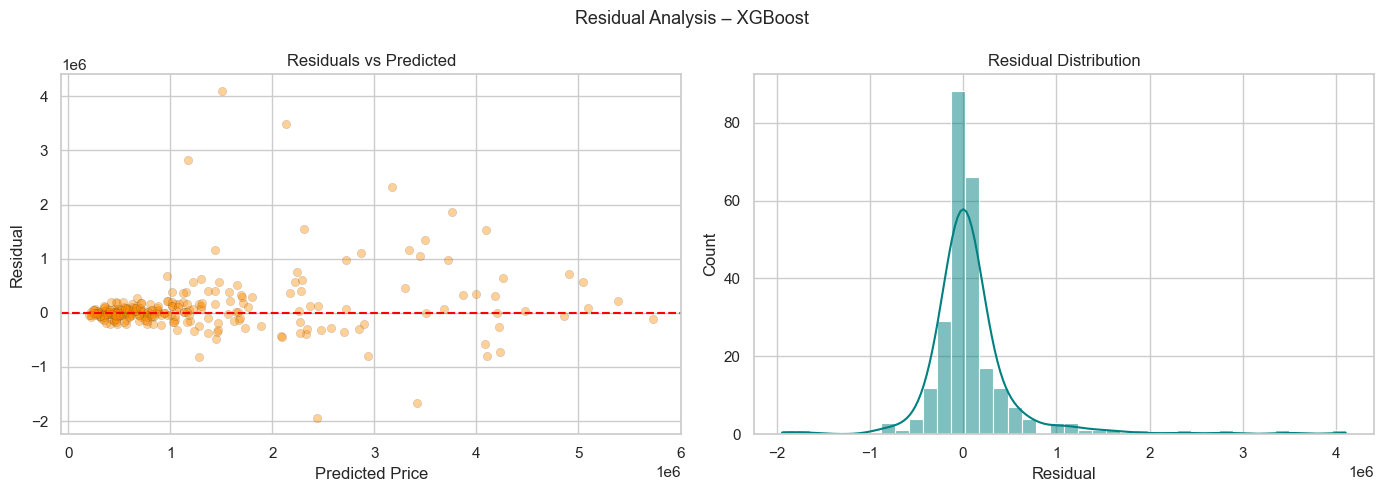

In [37]:
# Residual analysis
residuals = y_true - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_pred, residuals, alpha=0.4,
                color='darkorange', edgecolors='k', linewidths=0.2)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted Price')
axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs Predicted')

sns.histplot(residuals, bins=40, kde=True, ax=axes[1], color='teal')
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual')

plt.suptitle(f'Residual Analysis – {best_name}', fontsize=13)
plt.tight_layout()
plt.show()

---
## 6. Feature Importance Analysis

In [38]:
# Use the best tree-based model from the results
tree_model_map = {
    'Random Forest'     : rf,
    'Gradient Boosting' : gb,
    'XGBoost'           : xgb_model,
    'LightGBM'          : lgbm_model,
    'Decision Tree'     : dt,
}

best_tree = next(
    row.Model for row in results_df.itertuples()
    if row.Model in tree_model_map
)
print(f'Using {best_tree} for feature importance.')

feat_imp = pd.DataFrame({
    'Feature'   : X_train.columns,
    'Importance': tree_model_map[best_tree].feature_importances_
}).sort_values('Importance', ascending=False)

feat_imp

Using XGBoost for feature importance.


,Feature,Importance
5,fuel_type_enc,0.39
3,brand_enc,0.22
0,brand_rank,0.15
1,car_age,0.12
4,model_name_enc,0.05
2,log_distance,0.04
6,city_enc,0.02


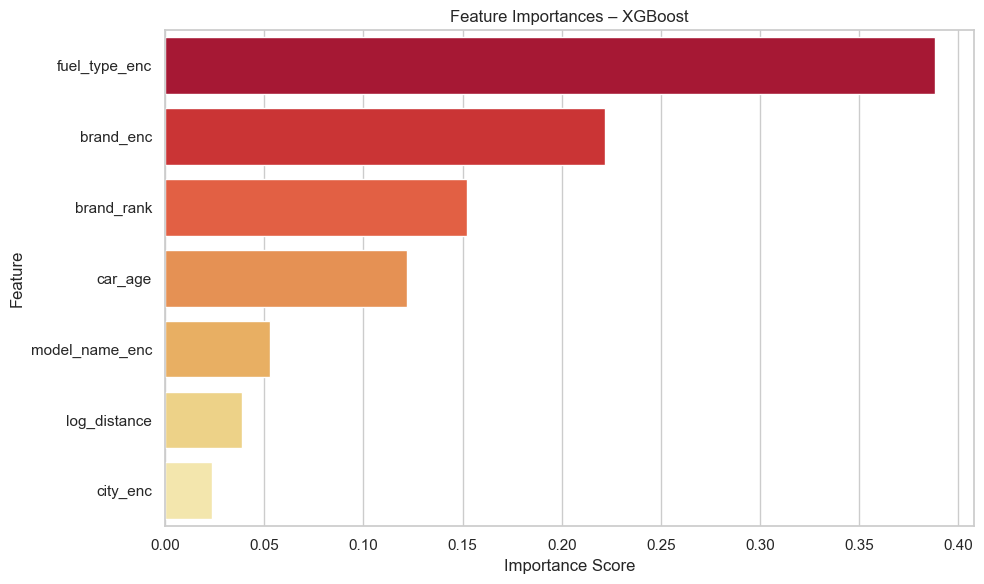

In [39]:
plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp, x='Importance', y='Feature', palette='YlOrRd_r')
plt.title(f'Feature Importances – {best_tree}')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

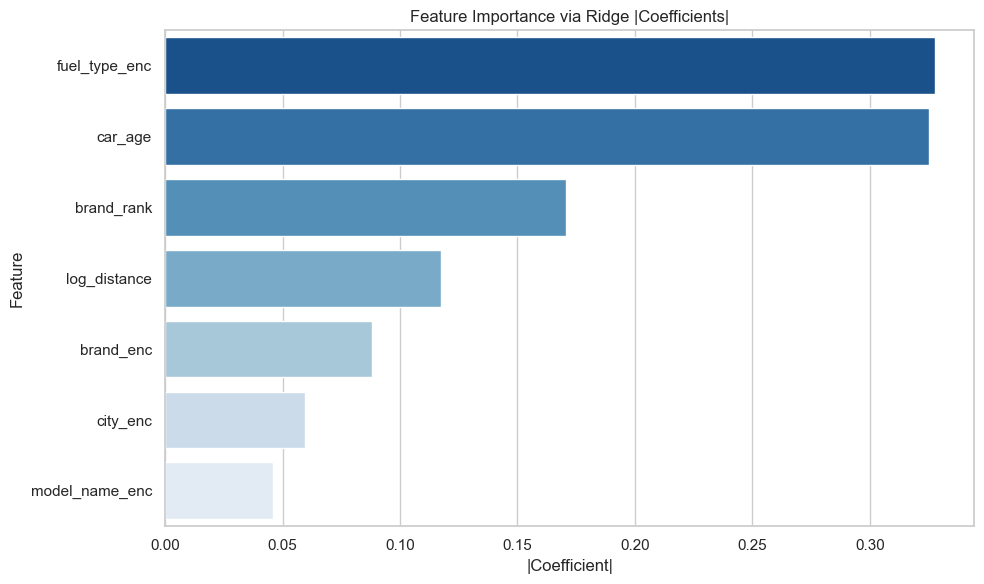

In [40]:
# Ridge coefficient magnitudes (linear model perspective)
ridge_imp = pd.DataFrame({
    'Feature'   : X_train.columns,
    'Abs Coef'  : np.abs(ridge.coef_)
}).sort_values('Abs Coef', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=ridge_imp, x='Abs Coef', y='Feature', palette='Blues_r')
plt.title('Feature Importance via Ridge |Coefficients|')
plt.xlabel('|Coefficient|')
plt.tight_layout()
plt.show()

---
## Summary & Conclusions

In [41]:
print('=' * 60)
print('  USED CARS PRICE PREDICTION – PROJECT SUMMARY')
print('=' * 60)
print()
print('Model Performance on Hold-out Test Set (sorted by R2):')
print(results_df.to_string(index=True))
print()
print(f'Best Performing Model : {best_name}')
print(f'  Test R²  : {best_row["Test R2"]}')
print(f'  Test MAE : {best_row["Test MAE"]}')
print(f'  Test RMSE: {best_row["Test RMSE"]}')
print()
print('Top 5 Most Important Features (Tree-based model):')
print(feat_imp.head(5).to_string(index=False))
print()
print('Key Insights:')
print('  1. Car age and distance travelled are the strongest price drivers.')
print('  2. Brand rank captures premium vs economy segment pricing.')
print('  3. Model name and brand carry significant resale-value information.')
print('  4. Fuel type moderately influences price (Diesel > Petrol > CNG).')
print('  5. City/location affects demand-side pricing.')
print('  6. Ensemble models (XGBoost / LightGBM / RF) consistently beat linear models.')

  USED CARS PRICE PREDICTION – PROJECT SUMMARY

Model Performance on Hold-out Test Set (sorted by R2):
               Model  CV R2 (train)  Test MAE  Test RMSE  Test R2
1            XGBoost           0.85 260370.19  553548.24     0.84
2           LightGBM           0.81 284360.43  581340.91     0.82
3  Gradient Boosting           0.84 303184.07  631821.04     0.79
4      Random Forest           0.73 346320.58  657868.31     0.77
5      Decision Tree           0.54 428081.70  752123.93     0.70
6  Linear Regression           0.42 678837.44 1124838.49     0.32
7   Lasso Regression           0.42 679461.02 1125979.70     0.32
8   Ridge Regression           0.42 680053.89 1127186.92     0.32

Best Performing Model : XGBoost
  Test R²  : 0.836
  Test MAE : 260370.19
  Test RMSE: 553548.24

Top 5 Most Important Features (Tree-based model):
       Feature  Importance
 fuel_type_enc        0.39
     brand_enc        0.22
    brand_rank        0.15
       car_age        0.12
model_name_enc     